In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Create a dummy dataset (Years of Experience vs Salary)
np.random.seed(42)
X = 2.5 * np.random.rand(100, 1) + 1  # Years of Experience (1 to 3.5 years)
y = 20000 + X * 12000 + np.random.randn(100, 1) * 2000  # Salary

# 2. Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale features for Gradient Descent
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Setup Complete! Salary data loaded into memory.")

Data Setup Complete! Salary data loaded into memory.


## Task 1: Basic Understanding of Linear Regression
* **Linear Regression:** A machine learning algorithm used to predict a continuous numerical value by drawing a straight "line of best fit" through data points.
* **Independent Variable (X):** The factor you use to make a prediction (e.g., Years of Experience).
* **Dependent Variable (y):** The target outcome you want to predict (e.g., Salary).

## Task 2: Residuals and Cost Function
* **Residuals:** The vertical distance (error) between the actual real data point ($y$) and the predicted line ($\hat{y}$). Formula: $\text{Residual} = y - \hat{y}$.
* **Mean Squared Error (MSE) Formula:** $$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
* **Large Residuals:** If residuals are very large, it means the model's line is far from the data, indicating a poorly fitted model with high error rates.

LR 0.01 -> Initial Loss: 1,093,688,701.74 | Final Loss: 409,515,866.20
LR 0.1 -> Initial Loss: 1,093,688,701.74 | Final Loss: 1,731,166.20
LR 0.5 -> Initial Loss: 1,093,688,701.74 | Final Loss: 1,695,357.71


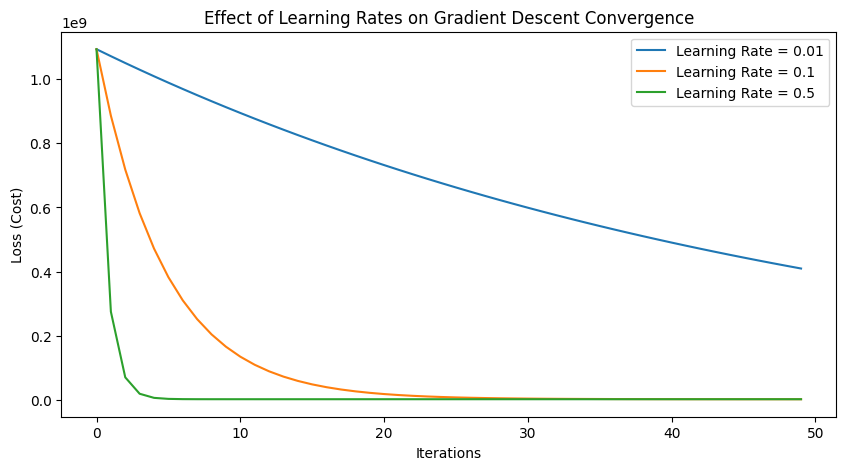

In [3]:
# Task 3 & 4: Gradient Descent with Different Learning Rates
def gradient_descent(X, y, lr, iterations=50):
    m, n = X.shape
    w = np.zeros((n, 1))
    b = 0
    loss_history = []
    
    for _ in range(iterations):
        y_pred = np.dot(X, w) + b
        dw = (1/m) * np.dot(X.T, (y_pred - y))
        db = (1/m) * np.sum(y_pred - y)
        w -= lr * dw
        b -= lr * db
        loss = (1/(2*m)) * np.sum((y_pred - y)**2)
        loss_history.append(loss)
    return loss_history

# Run experiments
rates = [0.01, 0.1, 0.5]
plt.figure(figsize=(10, 5))

for lr in rates:
    losses = gradient_descent(X_train_scaled, y_train, lr=lr)
    plt.plot(losses, label=f'Learning Rate = {lr}')
    print(f"LR {lr} -> Initial Loss: {losses[0]:,.2f} | Final Loss: {losses[-1]:,.2f}")

plt.title("Effect of Learning Rates on Gradient Descent Convergence")
plt.xlabel("Iterations")
plt.ylabel("Loss (Cost)")
plt.legend()
plt.show()

* **Best Learning Rate:** 0.1 performed best because it converges quickly and smoothly to the minimum loss without overshooting.
* **Too High Learning Rate (0.5):** If the learning rate is too high, the steps are too large, causing the model to overshoot the minimum and diverge (loss gets worse or bounces around).
* **Too Low Learning Rate (0.01):** It converges far too slowly, requiring too many iterations to find the best fit line.

Model Coefficient (Slope): 11678.92
Model Intercept: 20606.91
--- Evaluation Metrics ---
MAE: 1182.69
MSE: 2614798.05
RMSE: 1617.03
R² Score: 0.9686


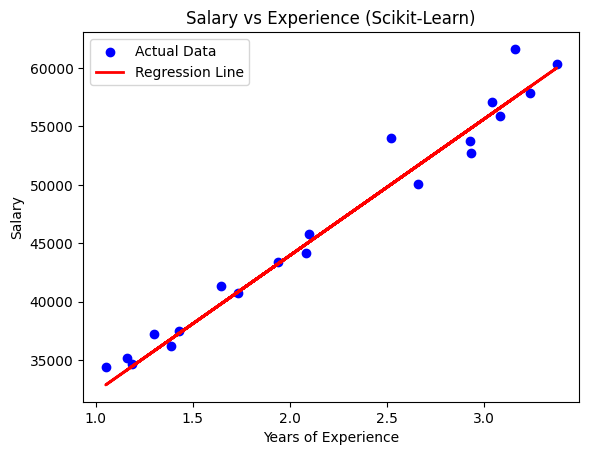

In [4]:
# Task 5 & 6: Scikit-Learn Model & Evaluation Metrics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Print Weights & Metrics
print(f"Model Coefficient (Slope): {model.coef_[0][0]:.2f}")
print(f"Model Intercept: {model.intercept_[0]:.2f}")
print("--- Evaluation Metrics ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")

# Plot actual vs predicted regression line
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience (Scikit-Learn)')
plt.legend()
plt.show()

## Task 5 & 6 Analysis
* **Relationship:** There is a strong positive linear relationship between Years of Experience and Salary. As experience increases, salary increases predictably.
* **Best Metric:** R² Score (Coefficient of Determination) is best for summarizing quality because it scales from 0 to 1, telling us exactly what percentage of variance in salary our model accounts for. RMSE is also excellent because it shows the average error margin in the actual unit (Dollars/Rupees).

## Task 7: LINE Assumptions of Linear Regression
* **L - Linearity:** The relationship between features and target must be a straight line.
* **I - Independence:** Observations must be independent of one another.
* **N - Normality:** The residual errors should be normally distributed around zero.
* **E - Equal Variance (Homoscedasticity):** The spread of residuals should stay constant across the regression line.

## Task 8: Critical Thinking Questions
* **Overfitting vs Underfitting:** Overfitting occurs when a model memorizes training noise and fails on new data. Underfitting happens when a model is too simple to capture the pattern at all.
* **Feature Scaling Importance:** If variables have different scales, Gradient Descent will take long, zig-zag paths to reach the minimum. Scaling creates an even terrain so the weights converge rapidly.
* **Simple vs Multiple Regression:** Simple regression uses only one feature to predict a target. Multiple regression uses two or more features simultaneously.
* **Data Splitting:** We split data into training and testing sets to evaluate our model on completely unseen data, proving its true real-world predictive performance.